In [2]:
from pathlib import Path
import numpy as np
import polars as pl
from sklearn.preprocessing import LabelEncoder
from src.tennis import fetch_jeff_sackmann_atp_data, read_tennis_data

In [3]:
files = fetch_jeff_sackmann_atp_data(dest_dir="data/atp_raw", start_year=2000, end_year=2025)

In [4]:
df_tennis = read_tennis_data(files)

In [5]:
df_tennis = df_tennis.with_columns([
    df_tennis["tourney_date"].cast(str).str.strptime(pl.Date, "%Y%m%d").alias("date"),
    (df_tennis['w_1stWon'] + df_tennis['w_2ndWon']).alias("w_serve_won"),
    (df_tennis['l_1stWon'] + df_tennis['l_2ndWon']).alias("l_serve_won"),
    ])

df_tennis = df_tennis.filter(pl.col("tourney_level").is_in(["G", "M", "A"]))
df_tennis = df_tennis.filter(pl.col("surface").is_in(["Hard", "Clay", "Grass"]))

In [6]:
# drop davis cup (D)
# drop final/season ending events (F) 
df_tennis['tourney_level'].value_counts()

tourney_level,count
str,u32
"""G""",13081
"""A""",41141
"""M""",14444


In [7]:
# create a link between winner_id -> winner_name, and loser_id -> loser_name. 
# I want a dataframe of unique player ids and names
def get_player_id_name_df(df: pl.DataFrame) -> pl.DataFrame:
    winner_df = df.select([
        pl.col("winner_id").alias("player_id"),
        pl.col("winner_name").alias("player_name")
    ]).unique()

    loser_df = df.select([
        pl.col("loser_id").alias("player_id"),
        pl.col("loser_name").alias("player_name")
    ]).unique()

    player_df = pl.concat([winner_df, loser_df]).unique().sort("player_id")

    return player_df

In [8]:
link_player_df = get_player_id_name_df(df_tennis)

In [9]:
link_player_df

player_id,player_name
i64,str
100644,"""Alexander Zverev"""
101086,"""Ronald Agenor"""
101150,"""Gianluca Pozzi"""
101167,"""Jaime Cortes"""
101185,"""Mark Woodforde"""
…,…
212309,"""Diego Dedura Palomero"""
212478,"""William Rejchtman Vinciguerra"""
212531,"""Nicolas Arseneault"""


In [10]:
server_names = np.concatenate([
    df_tennis['winner_id'].to_numpy(),
    df_tennis['loser_id'].to_numpy()
])

returner_names = np.concatenate([
    df_tennis['loser_id'].to_numpy(),
    df_tennis['winner_id'].to_numpy()
])

In [11]:
player_id_encoder = LabelEncoder()
surface_encoder = LabelEncoder()

server_ids = player_id_encoder.fit_transform(server_names)
returner_ids = player_id_encoder.transform(returner_names)
surface_ids = surface_encoder.fit_transform(df_tennis['surface'])

In [12]:
df_tennis.columns

['tourney_id',
 'tourney_name',
 'surface',
 'draw_size',
 'tourney_level',
 'tourney_date',
 'match_num',
 'winner_id',
 'winner_seed',
 'winner_entry',
 'winner_name',
 'winner_hand',
 'winner_ht',
 'winner_ioc',
 'winner_age',
 'loser_id',
 'loser_seed',
 'loser_entry',
 'loser_name',
 'loser_hand',
 'loser_ht',
 'loser_ioc',
 'loser_age',
 'score',
 'best_of',
 'round',
 'minutes',
 'w_ace',
 'w_df',
 'w_svpt',
 'w_1stIn',
 'w_1stWon',
 'w_2ndWon',
 'w_SvGms',
 'w_bpSaved',
 'w_bpFaced',
 'l_ace',
 'l_df',
 'l_svpt',
 'l_1stIn',
 'l_1stWon',
 'l_2ndWon',
 'l_SvGms',
 'l_bpSaved',
 'l_bpFaced',
 'winner_rank',
 'winner_rank_points',
 'loser_rank',
 'loser_rank_points',
 'date',
 'w_serve_won',
 'l_serve_won']

In [13]:
winner_serve_won = df_tennis['w_serve_won'].to_numpy()
winner_serve_total = df_tennis['w_svpt'].to_numpy()
loser_serve_won = df_tennis['l_serve_won'].to_numpy()
loser_serve_total = df_tennis['l_svpt'].to_numpy()

# Basic Hierarchial Regression 

## Serve + Return Effect

Note: This work is inspired and built off some tennis bayesian work I've seen by Martin Ingram. My goal here is to get more fluent with numpyro. 

Link 1: https://martiningram.github.io/historical-serve-return/  
Link 2: https://martiningram.github.io/papers/bayes_point_based.pdf  

In [26]:
from jax import random 
from jax.random import PRNGKey
from src.models import basic_serve_return_model
from src.model_helpers import model_prep_svi, svi_conv_plot
from numpyro.infer import autoguide

In [55]:
# note define model dict 
# prep the model info from function 
model_dct = {
    'X_intercept': 1,
    'n_players': len(player_id_encoder.classes_),    
    'server_idx': server_ids,
    'returner_idx': returner_ids,
    'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
    'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)    
}

/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_15748/1340137529.py:8: RuntimeWarning: invalid value encountered in cast
  'serve_attempts': np.concatenate([winner_serve_total, loser_serve_total]).astype(np.int32),
/var/folders/_7/3hw2lssx4zjb6_p04ljvgyjw0000gn/T/ipykernel_15748/1340137529.py:9: RuntimeWarning: invalid value encountered in cast
  'serve_pts_won': np.concatenate([winner_serve_won, loser_serve_won]).astype(np.int32)


In [56]:
svi_iters = 10000
adam_lr = 0.001
# note - use low rank, its faster when we have a lot of records
guide, basic_sv = model_prep_svi(basic_serve_return_model, iterations = svi_iters, lr = adam_lr, 
                                 guide_fn = autoguide.AutoLowRankMultivariateNormal)

In [57]:
basic_sv_results = basic_sv.run(random.PRNGKey(1), svi_iters, **model_dct)

100%|██████████| 10000/10000 [00:23<00:00, 433.32it/s, init loss: 3516192.0000, avg. loss [9501-10000]: 438326.1875]


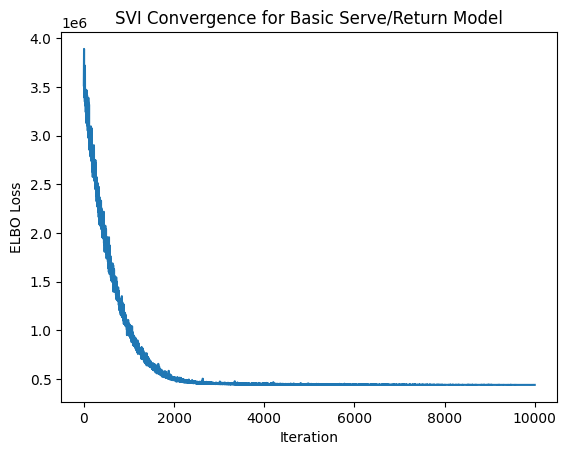

In [58]:
svi_conv_plot(basic_sv_results, 'Basic Serve/Return')

In [59]:
def get_posteriors(guide, params, sample_shape=(5000,), seed=1):
    posteriors = guide.sample_posterior(
        PRNGKey(seed), 
        params, 
        sample_shape=sample_shape
    )
    return posteriors


def posteriors_to_dataframe(posteriors, credible_interval=0.95):
    # Calculate alpha for credible intervals
    alpha = (1 - credible_interval) / 2
    lower_percentile = alpha * 100
    upper_percentile = (1 - alpha) * 100
    
    results = []
    
    for param_name, samples in posteriors.items():
        # Skip internal parameters
        if param_name.startswith("_"):
            continue
        
        # Convert to numpy array
        samples_array = np.array(samples)
        
        # Handle different shapes
        if samples_array.ndim == 1:
            # Single parameter
            results.append({
                'parameter': param_name,
                'mean': float(np.mean(samples_array)),
                'lower_ci': float(np.percentile(samples_array, lower_percentile)),
                'upper_ci': float(np.percentile(samples_array, upper_percentile))
            })
        else:
            # Multiple parameters (e.g., coefficient vector)
            # Flatten all but the first dimension (sample dimension)
            original_shape = samples_array.shape[1:]
            samples_flat = samples_array.reshape(samples_array.shape[0], -1)
            
            for idx in range(samples_flat.shape[1]):
                param_samples = samples_flat[:, idx]
                
                # Create parameter label
                if len(original_shape) == 1:
                    param_label = f"{param_name}[{idx}]"
                else:
                    # Multi-dimensional index
                    multi_idx = np.unravel_index(idx, original_shape)
                    param_label = f"{param_name}{list(multi_idx)}"
                
                results.append({
                    'parameter': param_label,
                    'mean': float(np.mean(param_samples)),
                    'lower_ci': float(np.percentile(param_samples, lower_percentile)),
                    'upper_ci': float(np.percentile(param_samples, upper_percentile))
                })
    
    return pl.DataFrame(results)

In [60]:
posteriors = get_posteriors(guide, basic_sv_results.params, sample_shape=(5000,), seed=1)
#
# Step 2: Create summary dataframe
summary_df = posteriors_to_dataframe(posteriors, credible_interval=0.95)
# print(summary_df)

In [61]:
summary_df.head()

parameter,mean,lower_ci,upper_ci
str,f64,f64,f64
"""intercept""",0.568412,0.549869,0.587263
"""mu_ret""",-0.041346,-0.061167,-0.021248
"""mu_server""",-0.11046,-0.120957,-0.09988
"""player_ret[0]""",0.17845,0.156684,0.200493
"""player_ret[1]""",-0.014815,-0.10244,0.07292


In [62]:
ret_results = summary_df.filter(pl.col("parameter").str.contains("player_ret")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("returner_index")
)

player_id_transformed = player_id_encoder.inverse_transform(ret_results['returner_index'])

ret_results = ret_results.with_columns([
    pl.Series(player_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [63]:
ret_results.sort('mean', descending=True)

parameter,mean,lower_ci,upper_ci,returner_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_ret[817]""",0.364411,0.34351,0.384026,817,104745,"""Rafael Nadal"""
"""player_ret[864]""",0.349147,0.328042,0.369733,864,104925,"""Novak Djokovic"""
"""player_ret[567]""",0.343005,0.314516,0.370576,567,103909,"""Guillermo Coria"""
"""player_ret[1524]""",0.328402,0.301541,0.355488,1524,207989,"""Carlos Alcaraz"""
"""player_ret[862]""",0.311406,0.290684,0.331484,862,104918,"""Andy Murray"""
…,…,…,…,…,…,…
"""player_ret[395]""",-0.327257,-0.354488,-0.300479,395,103333,"""Ivo Karlovic"""
"""player_ret[1338]""",-0.338357,-0.494921,-0.179186,1338,126340,"""Viktor Durasovic"""
"""player_ret[1088]""",-0.3412,-0.456996,-0.224526,1088,105874,"""Albano Olivetti"""


In [64]:
server_results = summary_df.filter(pl.col("parameter").str.contains("player_server")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("server_index")
)

server_id_transformed = player_id_encoder.inverse_transform(server_results['server_index'])

server_results = server_results.with_columns([
    pl.Series(server_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [65]:
server_results.sort('mean', descending=True)

parameter,mean,lower_ci,upper_ci,server_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_server[395]""",0.464959,0.417695,0.513786,395,103333,"""Ivo Karlovic"""
"""player_server[1055]""",0.439118,0.402932,0.47669,1055,105683,"""Milos Raonic"""
"""player_server[758]""",0.422567,0.387406,0.457409,758,104545,"""John Isner"""
"""player_server[610]""",0.416817,0.386631,0.445818,610,104053,"""Andy Roddick"""
"""player_server[540]""",0.382699,0.361268,0.404054,540,103819,"""Roger Federer"""
…,…,…,…,…,…,…
"""player_server[277]""",-0.504037,-0.677388,-0.332761,277,102956,"""Sultan Khalfan"""
"""player_server[1213]""",-0.507717,-0.701317,-0.319098,1213,106412,"""Lucas Gomez"""
"""player_server[1224]""",-0.546107,-0.77451,-0.318247,1224,108993,"""Abdulla Hajji"""


## Serve + Return + Surface Effect

In [66]:
from src.models import serve_return_surface_model

new_model_dct = model_dct.copy()
new_model_dct.update(
    surface_idx = np.concatenate([surface_ids, surface_ids]),
    surface_n = len(surface_encoder.classes_)
)

In [67]:
svi_iters = 10000
adam_lr = 0.001
# note - use low rank, its faster when we have a lot of records
surface_guide, surface_sv = model_prep_svi(serve_return_surface_model, 
                                           iterations = svi_iters, 
                                           lr = adam_lr, 
                                           guide_fn = autoguide.AutoLowRankMultivariateNormal)

In [68]:
new_model_dct

{'X_intercept': 1,
 'n_players': 1641,
 'server_idx': array([ 343,  193,  374, ..., 1398, 1259, 1423], shape=(137332,)),
 'returner_idx': array([  15,  200,  114, ..., 1357, 1347, 1615], shape=(137332,)),
 'serve_attempts': array([ 96,  76,  55, ..., 114,  46,  67], shape=(137332,), dtype=int32),
 'serve_pts_won': array([67, 52, 37, ..., 82, 29, 36], shape=(137332,), dtype=int32),
 'surface_idx': array([2, 2, 2, ..., 2, 2, 2], shape=(137332,)),
 'surface_n': 3}

In [69]:
surface_sv_results = surface_sv.run(random.PRNGKey(1), svi_iters, **new_model_dct)

100%|██████████| 10000/10000 [00:32<00:00, 310.88it/s, init loss: 5348881.5000, avg. loss [9501-10000]: 436232.5312]


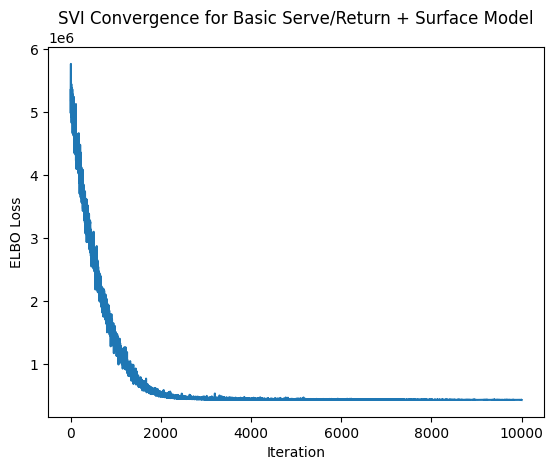

In [70]:
svi_conv_plot(surface_sv_results, 'Basic Serve/Return + Surface')

In [71]:
posteriors = get_posteriors(surface_guide, surface_sv_results.params, sample_shape=(5000,), seed=1)
#
surface_summary_df = posteriors_to_dataframe(posteriors, credible_interval=0.95)
surface_summary_df.head()

parameter,mean,lower_ci,upper_ci
str,f64,f64,f64
"""intercept""",0.654373,0.634144,0.67477
"""mu_ret""",-0.046446,-0.066039,-0.026773
"""mu_server""",-0.094663,-0.105013,-0.084683
"""mu_surface""",-0.084008,-0.322297,0.150989
"""player_ret[0]""",0.16996,0.14648,0.19302


In [72]:
surface_results = surface_summary_df.filter(pl.col("parameter").str.contains("surface_effect")).with_columns(
    pl.col("parameter")
    .str.extract(r"\[(\d+)\]", 1)
    .cast(pl.Int64, strict=False)
    .alias("surface_index")
)

surface_names = surface_encoder.inverse_transform(surface_results["surface_index"].to_numpy())

surface_results = surface_results.with_columns(
    pl.Series(surface_names).alias("surface")
).select(["surface", "mean", "lower_ci", "upper_ci"]).sort("mean", descending=True)

surface_results

surface,mean,lower_ci,upper_ci
str,f64,f64,f64
"""Grass""",-0.005132,-0.034642,0.025226
"""Hard""",-0.085506,-0.115512,-0.054664
"""Clay""",-0.161373,-0.194526,-0.126871


In [78]:
ret_surface_results = surface_summary_df.filter(pl.col("parameter").str.contains("player_ret")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("returner_index")
)

player_id_transformed = player_id_encoder.inverse_transform(ret_surface_results['returner_index'])

ret_surface_results = ret_surface_results.with_columns([
    pl.Series(player_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [ ]:
ret_surface_results.sort('mean', descending=True)

parameter,mean,lower_ci,upper_ci,returner_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_ret[817]""",0.35112,0.329303,0.372392,817,104745,"""Rafael Nadal"""
"""player_ret[864]""",0.346902,0.322197,0.371321,864,104925,"""Novak Djokovic"""
"""player_ret[1524]""",0.322165,0.294423,0.34905,1524,207989,"""Carlos Alcaraz"""
"""player_ret[862]""",0.319448,0.293209,0.345004,862,104918,"""Andy Murray"""
"""player_ret[567]""",0.316501,0.288833,0.344248,567,103909,"""Guillermo Coria"""
…,…,…,…,…,…,…
"""player_ret[395]""",-0.320364,-0.348898,-0.292077,395,103333,"""Ivo Karlovic"""
"""player_ret[1088]""",-0.325162,-0.440839,-0.208821,1088,105874,"""Albano Olivetti"""
"""player_ret[1338]""",-0.327542,-0.489743,-0.170519,1338,126340,"""Viktor Durasovic"""


In [80]:
server_surface_results = surface_summary_df.filter(pl.col("parameter").str.contains("player_server")).with_columns(
        pl.col("parameter")
        .str.extract(r"\[(\d+)\]", 1)
        .cast(pl.Int64, strict=False)
        .alias("server_index")
)

server_id_transformed = player_id_encoder.inverse_transform(server_surface_results['server_index'])

server_surface_results = server_surface_results.with_columns([
    pl.Series(server_id_transformed).alias("player_id")
]).join(link_player_df, on="player_id", how="left")

In [81]:
server_surface_results.sort('mean', descending=True)

parameter,mean,lower_ci,upper_ci,server_index,player_id,player_name
str,f64,f64,f64,i64,i64,str
"""player_server[395]""",0.466352,0.424451,0.509139,395,103333,"""Ivo Karlovic"""
"""player_server[1055]""",0.439932,0.410568,0.469824,1055,105683,"""Milos Raonic"""
"""player_server[758]""",0.429299,0.397737,0.460551,758,104545,"""John Isner"""
"""player_server[610]""",0.413803,0.381332,0.446357,610,104053,"""Andy Roddick"""
"""player_server[540]""",0.384709,0.363258,0.406055,540,103819,"""Roger Federer"""
…,…,…,…,…,…,…
"""player_server[1213]""",-0.491739,-0.676848,-0.30427,1213,106412,"""Lucas Gomez"""
"""player_server[277]""",-0.500782,-0.675707,-0.331976,277,102956,"""Sultan Khalfan"""
"""player_server[1224]""",-0.518716,-0.740945,-0.292283,1224,108993,"""Abdulla Hajji"""


# Hierarchial Regression w/Time Component 

Goal: To get player effects varying over time. 

(1) AR(1) Covariance in MultiVariate Normal    
(2) State Space Model   